# Plot all games

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# ---------
# Load CSVs
# ---------
csv1 = Path("/Users/Student/wm_inference_diffusion/src/planning_percentage_0_05_by_env_and_mode.csv")
csv2 = Path("/Users/Student/wm_inference_diffusion/src/zero_roll_by_env_and_mode.csv")
csv3 = Path("/Users/Student/wm_inference_diffusion/src/planning_percentage_0_10_by_env_and_mode.csv")
csv4 = Path("/Users/Student/wm_inference_diffusion/src/planning_percentage_0_20_by_env_and_mode.csv")

df1 = pd.read_csv(csv1)
df2 = pd.read_csv(csv2)
df3 = pd.read_csv(csv3)
df4 = pd.read_csv(csv4)

df1["experiment"] = "5percent"
df2["experiment"] = "baseline"
df3["experiment"] = "10percent"
df4["experiment"] = "20percent"

# Combine
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

# Keep only what you said you care about
keep_cols = [
    "env_type", "mode", "experiment", "n_runs",
    "reward_mean", "reward_std",
    "ep_length_mean", "ep_length_std",
]
df = df[keep_cols].copy()

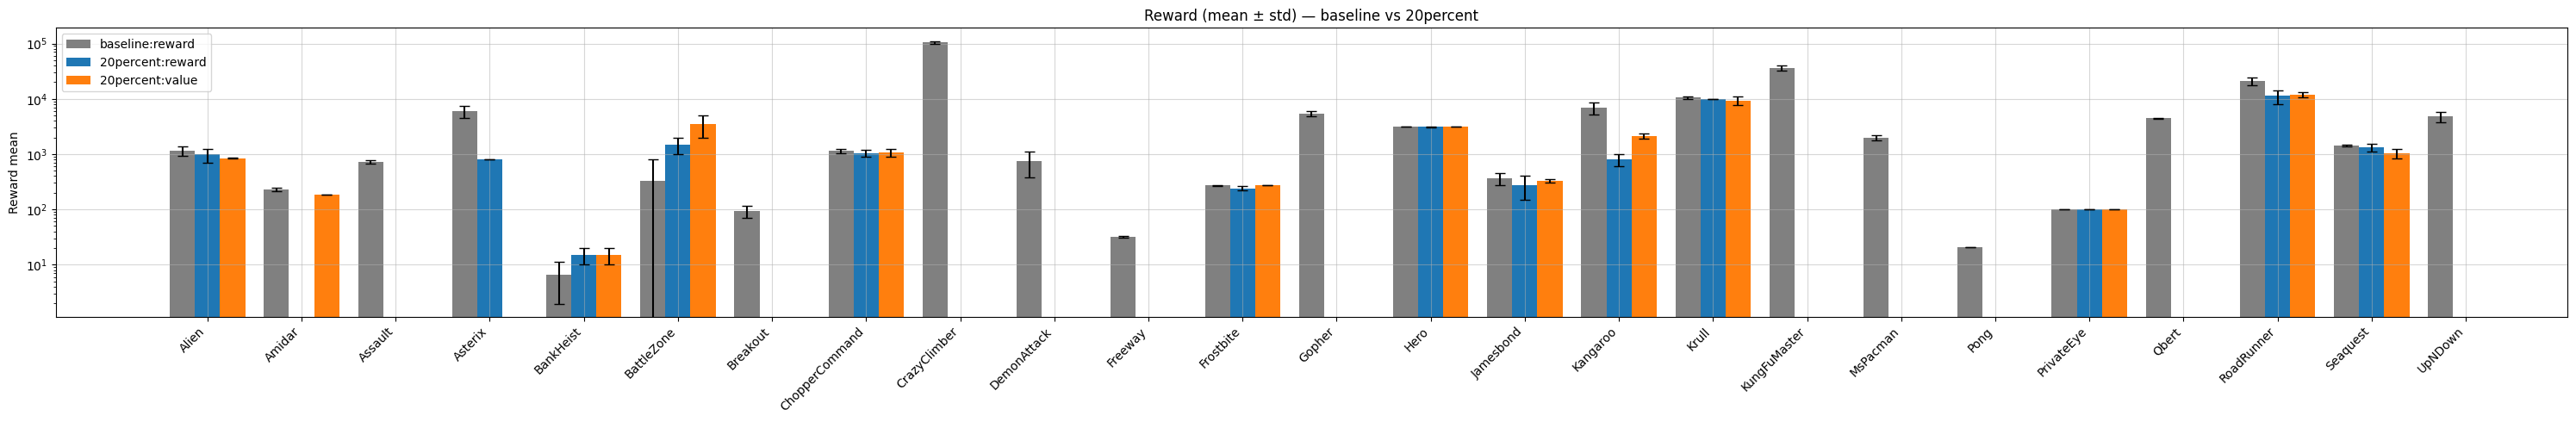

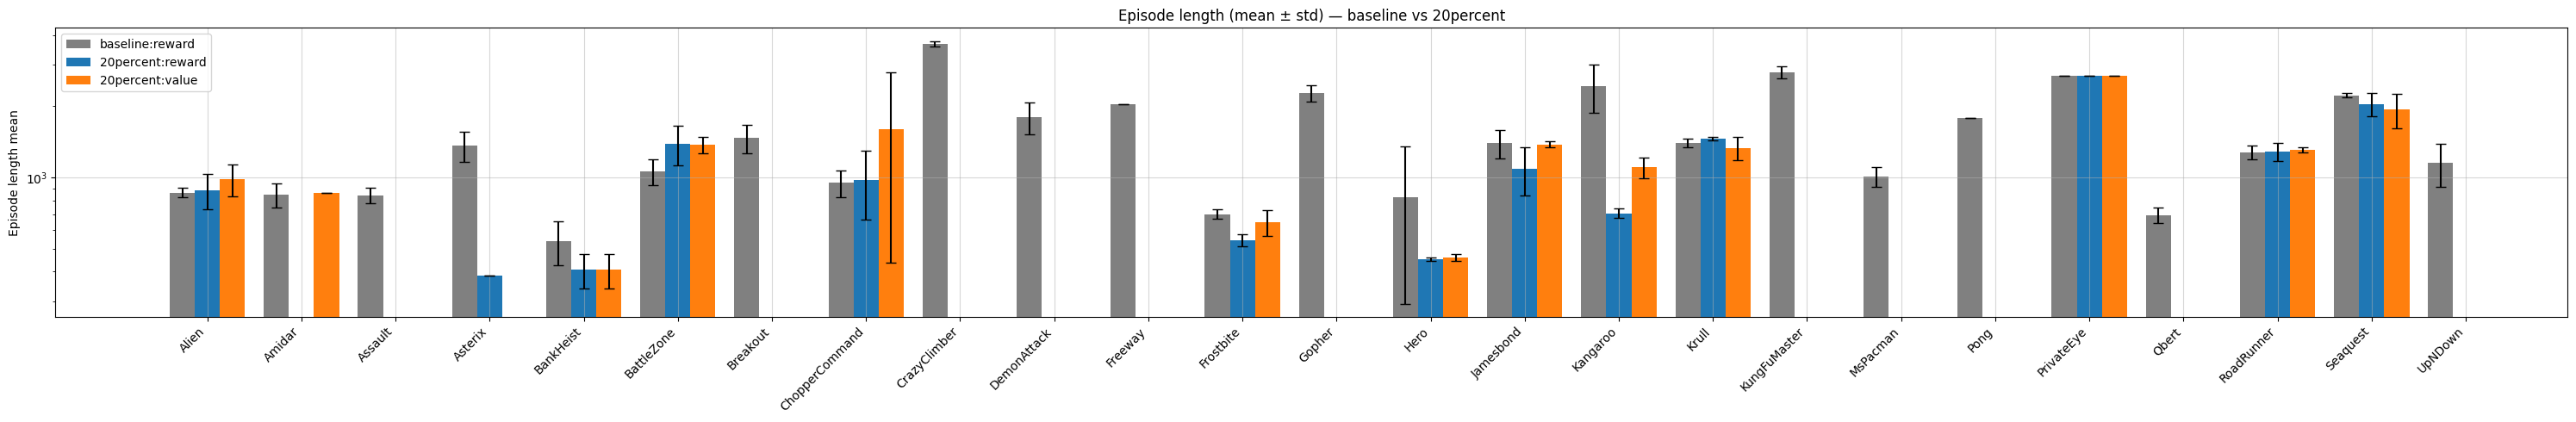

In [6]:
# ----------------------------
# Experiment selector
# ----------------------------
EXP_ID = "20percent"   # <-- change this to "exp2", "exp3", etc.

# ----------------------------
# Colour scheme (semantic)
# ----------------------------
COLOR_MAP = {
    "baseline:reward": "grey",
    f"{EXP_ID}:reward": "tab:blue",
    f"{EXP_ID}:value": "tab:orange",
}

# ----------------------------
# Helper: grouped bar + errors
# ----------------------------
def plot_grouped_bars(df, value_col, err_col, title, ylabel):
    df = df.dropna(subset=[value_col]).copy()

    # One label per bar
    df["series"] = df["experiment"] + ":" + df["mode"]

    envs = sorted(df["env_type"].unique())

    # Series we *want* to show
    all_series = [
        "baseline:reward",
        f"{EXP_ID}:reward",
        f"{EXP_ID}:value",
    ]

    # Keep only series present in the data
    present = set(df["series"].unique())
    series = [s for s in all_series if s in present]

    # Matrices: env × series
    y = np.full((len(envs), len(series)), np.nan)
    e = np.full((len(envs), len(series)), np.nan)

    for i, env in enumerate(envs):
        sub = df[df["env_type"] == env]
        for j, s in enumerate(series):
            row = sub[sub["series"] == s]
            if row.empty:
                continue
            y[i, j] = float(row[value_col].iloc[0])
            e[i, j] = (
                float(row[err_col].iloc[0])
                if err_col in row and pd.notna(row[err_col].iloc[0])
                else 0.0
            )

    # Plot
    x = np.arange(len(envs))
    width = 0.8 / max(1, len(series))

    plt.figure(figsize=(max(8, 1.2 * len(envs)), 5))
    for j, s in enumerate(series):
        offset = (j - (len(series) - 1) / 2) * width
        plt.bar(
            x + offset,
            y[:, j],
            width=width,
            yerr=e[:, j],
            capsize=4,
            label=s,
            color=COLOR_MAP.get(s, "black"),
        )

    plt.xticks(x, envs, rotation=45, ha="right")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.5)
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

# ----------------
# Reward chart
# ----------------
plot_grouped_bars(
    df,
    value_col="reward_mean",
    err_col="reward_std",
    title=f"Reward (mean ± std) — baseline vs {EXP_ID}",
    ylabel="Reward mean",
)

# -------------------------
# Episode length chart
# -------------------------
plot_grouped_bars(
    df,
    value_col="ep_length_mean",
    err_col="ep_length_std",
    title=f"Episode length (mean ± std) — baseline vs {EXP_ID}",
    ylabel="Episode length mean",
)

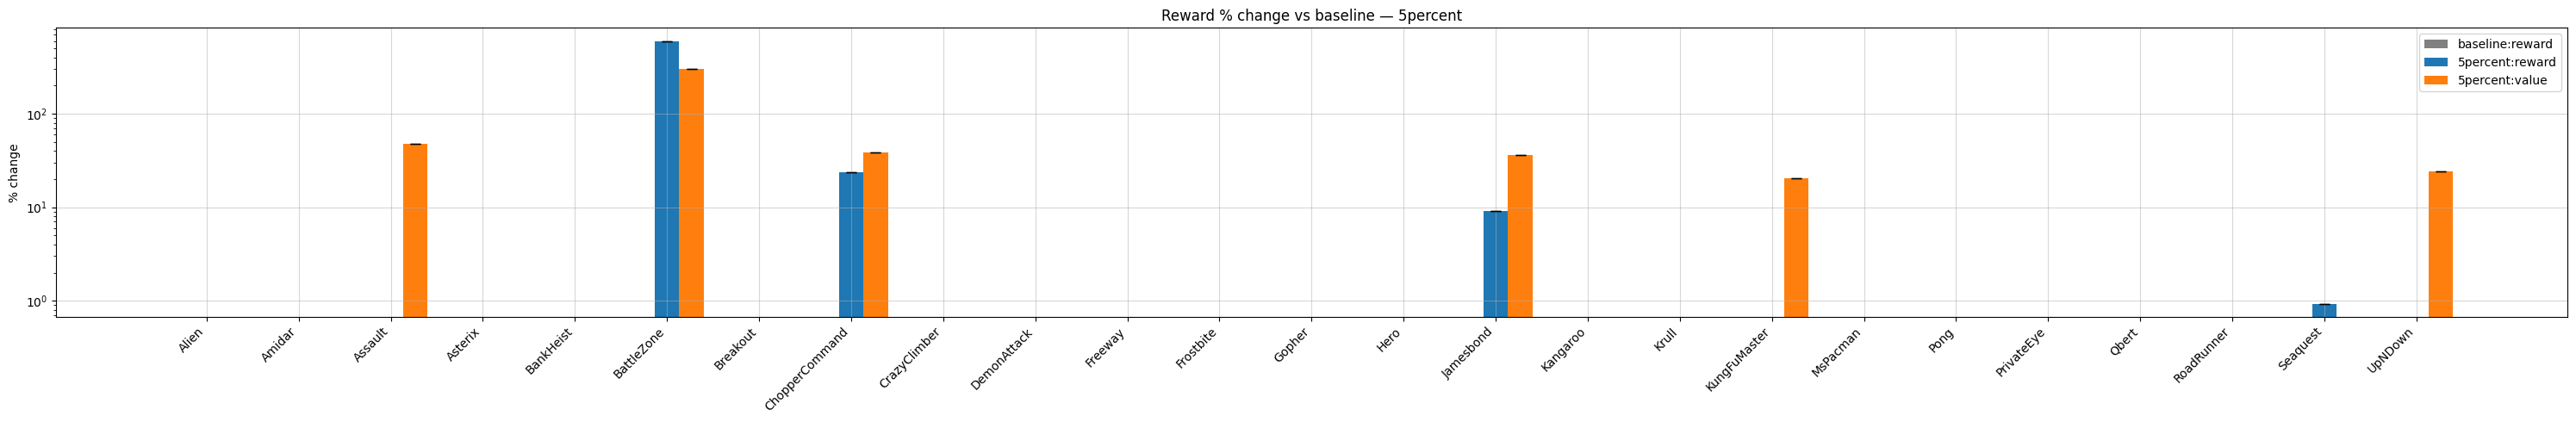

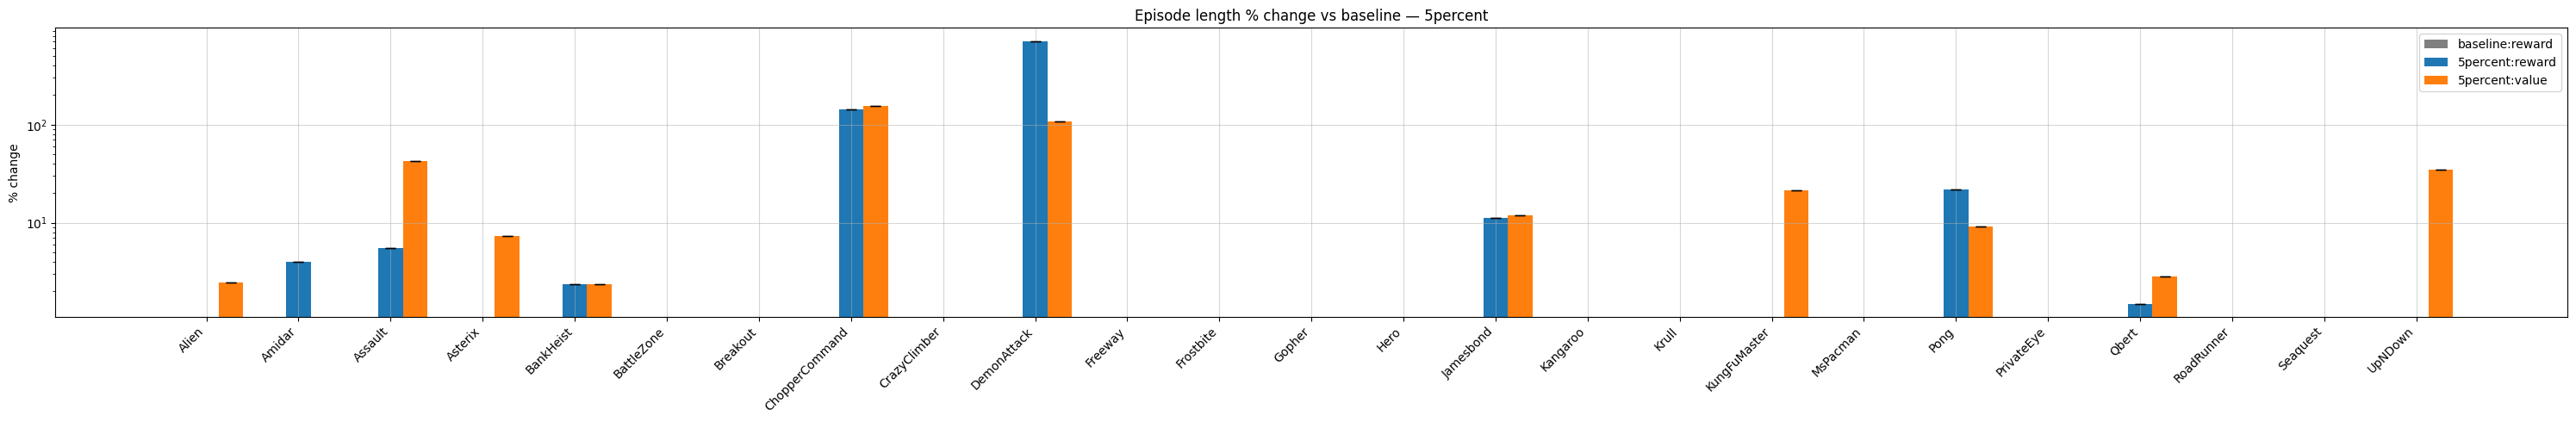

In [4]:
def add_delta_vs_baseline(df, exp_id=EXP_ID):
    df = df.copy()

    # Baseline (reward) per env
    base = (
        df[df["experiment"].eq("baseline") & df["mode"].eq("reward")][
            ["env_type", "reward_mean", "reward_std", "ep_length_mean", "ep_length_std"]
        ]
        .rename(
            columns={
                "reward_mean": "base_reward_mean",
                "reward_std": "base_reward_std",
                "ep_length_mean": "base_ep_mean",
                "ep_length_std": "base_ep_std",
            }
        )
    )

    df = df.merge(base, on="env_type", how="left")

    # Percent change vs baseline
    df["reward_pct"] = 100.0 * (df["reward_mean"] - df["base_reward_mean"]) / df["base_reward_mean"]
    df["ep_len_pct"] = 100.0 * (df["ep_length_mean"] - df["base_ep_mean"]) / df["base_ep_mean"]

    # Keep only baseline + selected experiment (and reward/value modes)
    keep_experiments = {"baseline", exp_id}
    df = df[df["experiment"].isin(keep_experiments)].copy()

    return df

df2 = add_delta_vs_baseline(df, exp_id=EXP_ID)

plot_grouped_bars(
    df2,
    "reward_pct",
    None,
    title=f"Reward % change vs baseline — {EXP_ID}",
    ylabel="% change",
)

plot_grouped_bars(
    df2,
    "ep_len_pct",
    None,
    title=f"Episode length % change vs baseline — {EXP_ID}",
    ylabel="% change",
)